# **ENDG 511 - Lab 1: Introduction to Deep Neural Networks using TensorFlow**

This colab notebook provides code and a framework for ***Lab 1***. You can work out your solutions here. The example in this lab was inspired by https://www.tensorflow.org/tutorials/quickstart/beginner, with some modifications and additions.


## Goals

In this lab, you will be introduced to the baiscs of TensorFlow and Keras, and you will learn how to use them to create deep learning models. The goals of this lab are:

- Understand the basic workflow for creating models in TensorFlow.
- Understand how to train TensorFlow models.
- Evaluate models in terms of accuracy, size and inference time.
- Understand how different model parameters can impact accuracy, size and inference time

## Layout
This lab is split into **two** parts. 
- **Part 1**: Run through the full example to gain familiarity with TensorFlow. And complete the exercises.
- **Part 2**: Convlutional Neural Netowrks Using TensorFlow. And complete the exercises.

# **Part 1**: Neural Network Machine Learning Model Using TensorFlow

This part of the lab demonstrates building and training a Neural Network to classify MNIST images. This tutorial uses TensorFlow and it is meant to give you a better understanding of how to build, train and evaluate machine learning models using TensorFlow.

### Import TensorFlow and Other Required Modules

In [1]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import time
import tempfile

### Download and prepare the MNIST dataset

The MNIST dataset is an acronym that stands for the Modified National Institute of Standards and Technology dataset. It is a dataset of 60,000 small square 28×28 pixel grayscale images of handwritten single digits between 0 and 9


In [2]:
mnist = tf.keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

### Verify the data

To verify that the dataset looks correct, let's plot the first 25 images from the training set and display the class name below each image:


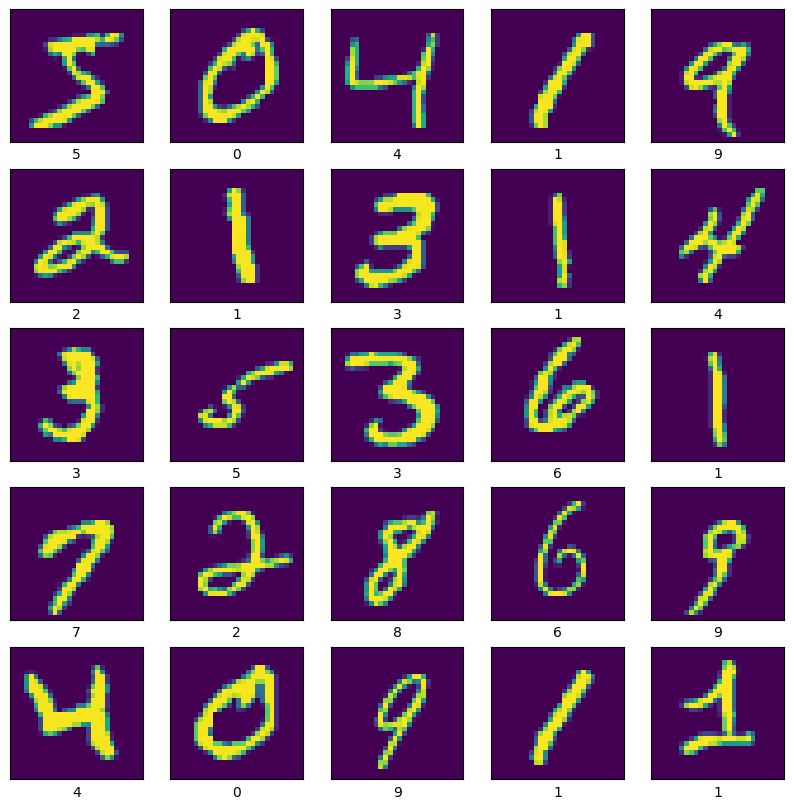

In [3]:
class_names = ['0', '1', '2', '3', '4',
               '5', '6', '7', '8', '9']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i]])
plt.show()

### Build Machine Learning Model

***Sequential*** is useful for stacking layers where each layer has one input tensor and one output tensor. Layers are functions with a known mathematical structure that can be reused and have trainable variables. Most TensorFlow models are composed of layers. This model uses the Flatten, Dense, and Dropout layers.

In [24]:
neurons=128
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(neurons, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10)
])

c:\Users\jenny\anaconda3\envs\endg511\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Let's display the architecture of our model:

In [25]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Save and Load Model
Let us save and load the model before training. This allows us to save the randomized weights and biases and make more accurate comparisons. We will use the saved model in the exercise section.

In [26]:
# Save your model
model.save(f'part1_model_{neurons}.h5')

In [36]:


# Recreate the exact same model, including its weights and the optimizer
new_model = tf.keras.models.load_model(f'part1_model_{neurons}.h5')

# Show the model architecture
new_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Compile and train the model

When compiling a model, an optimizer, a loss function and metrics need to be defined. 

- Optimizer: The Adam optimizer is the most popular optimizer and generally works well for classification and regression problems. It is based of gradient descent algorithms.
- Loss Function: The loss function is the function that computes the distance between the current output of the algorithm and the expected output. These functions need to be chosen depending on the application, the SparseCategoricalCrossentropy for example computes the crossentropy loss between the labels and predictions.
- Metrics: A metric is a function that is used to judge the performance of your model. This could be accuracy, mean squared error, cosine similarity or whatever metric works best for your use case.

In [37]:
learning_rate=1.5#0.001
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
new_model.compile(optimizer=optimizer,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = new_model.fit(train_images, train_labels, epochs=5, 
                    validation_data=(test_images, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.1083 - loss: 12.2891 - val_accuracy: 0.1034 - val_loss: 2.6352
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.1038 - loss: 2.4549 - val_accuracy: 0.1016 - val_loss: 2.4559
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.1021 - loss: 2.4527 - val_accuracy: 0.1034 - val_loss: 2.4311
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.1024 - loss: 2.4583 - val_accuracy: 0.1016 - val_loss: 2.3859
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.1022 - loss: 2.4982 - val_accuracy: 0.1032 - val_loss: 2.5035


### Plot accuracy and loss graphs

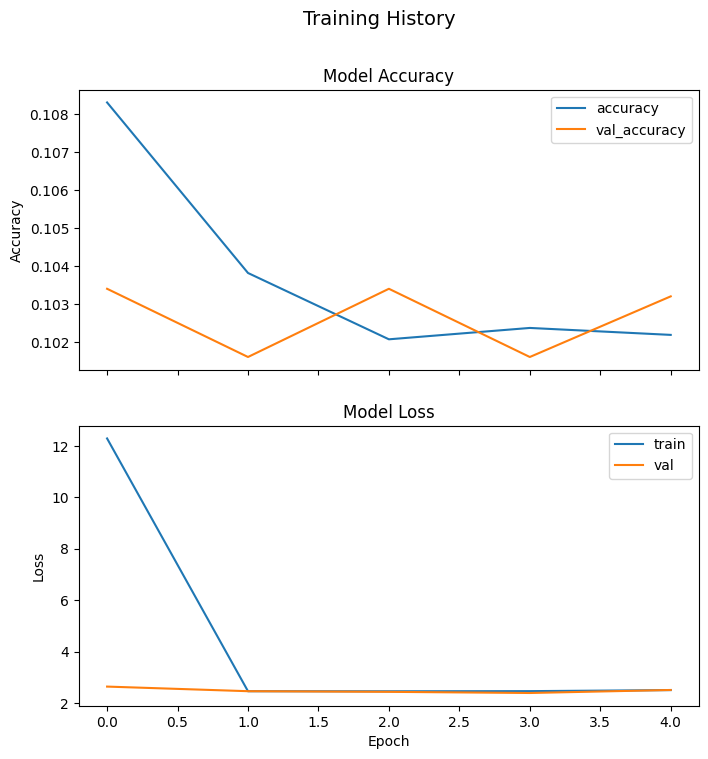

In [38]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)


axs[0].plot(history.history['accuracy'], label='accuracy')
axs[0].plot(history.history['val_accuracy'], label='val_accuracy')
axs[0].set_title('Model Accuracy')
axs[0].set_ylabel('Accuracy')
axs[0].legend(loc='best')



axs[1].plot(history.history['loss'], label='train')
axs[1].plot(history.history['val_loss'], label='val')
axs[1].set_title('Model Loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend(loc='best')


fig.suptitle('Training History', fontsize=14)


fig.savefig(f'Model_History_LR_{learning_rate}_{neurons}_neurons.png',
            dpi=300,
            bbox_inches='tight')

plt.show()


### Evaluate the model
There are many metrics that can be used to evaluate a model. We will focus on three metrics for this lab:
1. Model Loss and Accuracy
2. Model Size
3. Inference time

In [39]:
# Evaluate prediction accuracy
test_loss, test_acc = new_model.evaluate(test_images,  test_labels, verbose=2)


# Evaluate Model Size
def get_gzipped_model_size(file):
  # Returns size of gzipped model, in bytes.
  import os
  import zipfile

  _, zipped_file = tempfile.mkstemp('.zip')
  with zipfile.ZipFile(zipped_file, 'w', compression=zipfile.ZIP_DEFLATED) as f:
    f.write(file)

  return os.path.getsize(zipped_file)


# Evaluate Inference Time
startTime = time.time()
prediction = new_model.predict(test_images)
executionTime = (time.time() - startTime)/len(test_images)

# Print
print('\nModel Accuracy:', test_acc*100, '%')
print("Model Size: %.2f bytes" % (get_gzipped_model_size(f'part1_model_{neurons}.h5')))
print("Inference Time is", executionTime, "s")

313/313 - 1s - 4ms/step - accuracy: 0.1032 - loss: 2.5035
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Model Accuracy: 10.320000350475311 %
Model Size: 375085.00 bytes
Inference Time is 0.00016758909225463866 s


### Excercies (2.5 points)


Question 1: Load the untrained model. Change the learning rate to 1.5, recompile and retrain the model and display the accuracy and loss plots. What do you observe? **(0.5 point)**



<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">

<div>
<strong>0.001 Learning rate</strong><br>
Model Accuracy: 97.53000140190125 %

Model Size: 375085.00 bytes

Inference Time is 0.00012310280799865723 s
</div>

<div>
<strong>1.5 learning rate</strong><br>
Model Accuracy: 10.320000350475311 %

Model Size: 375085.00 bytes

Inference Time is 0.00016758909225463866 s
</div>

</div>

<p align="left">
  <img src="Model_History_LR_0.001_128_neurons.png" width="45%">
  <img src="Model_History_LR_1.5.png" width="45%">
</p>

Between the two learning rates it is clear that 1.5 is too high and the model is unable to properly realize the features in the images, shown by the low accuracy, highly random learning curves and the loss converging way too early and at a very high loss.


Question 2: Load the untrained model. Change the learning rate to 0.0001, recompile and retrain the model and display the accuracy and loss plots. What do you observe? **(0.5 point)**


<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">

<div>
<strong>0.001 Learning rate</strong><br>
Model Accuracy: 97.53000140190125 %

Model Size: 375085.00 bytes

Inference Time is 0.00012310280799865723 s
</div>

<div>
<strong>0.0001 learning rate</strong><br>
Model Accuracy: 95.10999917984009 %

Model Size: 375085.00 bytes

Inference Time is 0.0001228421449661255 s
</div>

</div>

<p align="left">
  <img src="Model_History_LR_0.001_128_neurons.png" width="45%">
  <img src="Model_History_LR_0.0001_128_neurons.png" width="45%">
</p>

Between the two learning rates 0.001 still performs better, but barely. The main difference between the models is the time for training to end up at the same result. 0.0001 learning rate took nearly x10 they time to train. There is also the possibility of over-fitting when the learning rate is too small and the model will become too well fit for the type of data in the training set.

Question 3: Rebuild the model with 8 neurons in the first Dense layer instead of 128. Then recompile and retrain the model and save it. Finally compare the new size, accuracy and inference time to the original model. **(0.75 point)**


<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">

<div>
<strong>128 neurons in first Dense layer</strong><br>
Model Accuracy: 97.680002450943 %

Model Size: 375102.00 bytes

Inference Time is 8.878178596496582e-05 s
</div>

<div>
<strong>8 neurons in first Dense layer</strong><br>
Model Accuracy: 89.35999870300293 %

Model Size: 25370.00 bytes

Inference Time is 7.119789123535157e-05 s
</div>

</div>

<p align="left">
  <img src="model_128_neurons.jpg" width="45%">
  <img src="model_8_neurons.jpg" width="45%">
</p>

The original model with 128 neurons is nearly 15x larger than the 8 neuron model with sizes of 375 kbytes and 25 kbytes respectively. The decreased size of the 8 neuron model resulted in worst accuracy and a similar longer interference time. 8 neurons is not enough to be able to account for the features in the images, resulting in features that are not connected enough to predict images. 

Question 4: Rebuild the model with 2048 neurons in the first Dense layer instead of 128. Then recompile and retrain the model and save it. Finally compare the new size, accuracy and inference time to the original model. **(0.75 point)**

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">

<div>
<strong>128 neuron in first Dense layer</strong><br>
Model Accuracy: 97.680002450943 %

Model Size: 375102.00 bytes

Inference Time is 8.878178596496582e-05 s
</div>

<div>
<strong>2048 neuron in first Dense layer</strong><br>
Model Accuracy: 97.50000238418579 %

Model Size: 6006568.00 bytes

Inference Time is 0.00017930598258972168 s
</div>

</div>

<p align="left">
  <img src="model_128_neurons.jpg" width="45%">
  <img src="model_2048_neurons.jpg" width="45%">
</p>

The original model with 128 neurons is nearly 16x smaller than the 2048 neuron model with sizes of 375 kbytes and 6 Mbytes respectively. The increased size of the 2048 neuron model resulted in slightly worst accuracy and a significantly longer interference time. 2048 neurons is way too many neurons for the number of features, possibly leading to features being broken up of the model being overfit. 

# **Part 2**: Convlutional Neural Netowrks Using TensorFlow

### Introduction:

Convolutional Neural Networks (CNN) are distinguished by their ability to identify patterns and features in images (e.g. edges, lines, circles or even objects). CNN's are widely adopted in computer vision applications and found success in audio signals and text. 


A typical Convolutional neural network is composed mainly of three types of layers:

* **Convolutional layer:** The core building block of a CNN, which consists of Filters or kernels to detect features. Generally, the first convolutional layers detect simple features (e.g. edges) and later layers identify objects. 
* **Pooling layer:** Reduces the spatial size of the feature maps so having fewer learnable weights and less computation cost.
* **Fully-connected layer:**  Known as the output layer, where the last identified feature maps are flattened and connected to dense layers for the classification task.



### Import TensorFlow and Other Required Modules

In [228]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import time
import tempfile

### Download and prepare the MNIST dataset
Similar to Part 1, loading the MNIST dataset and performing normalization to improve the training performance and speed.

In [229]:
mnist = tf.keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

### Build Machine Learning Model
In this part, we will build the LeNet-5 CNN model, one of the earliest CNN architectures proposed by Yann LeCun and others for recognizing handwritten and machine-printed characters.

The LeNet-5 architecture cosisits of 2 convolutional layers, 2 pooling layers and fully connected layers as shown in the figure below.

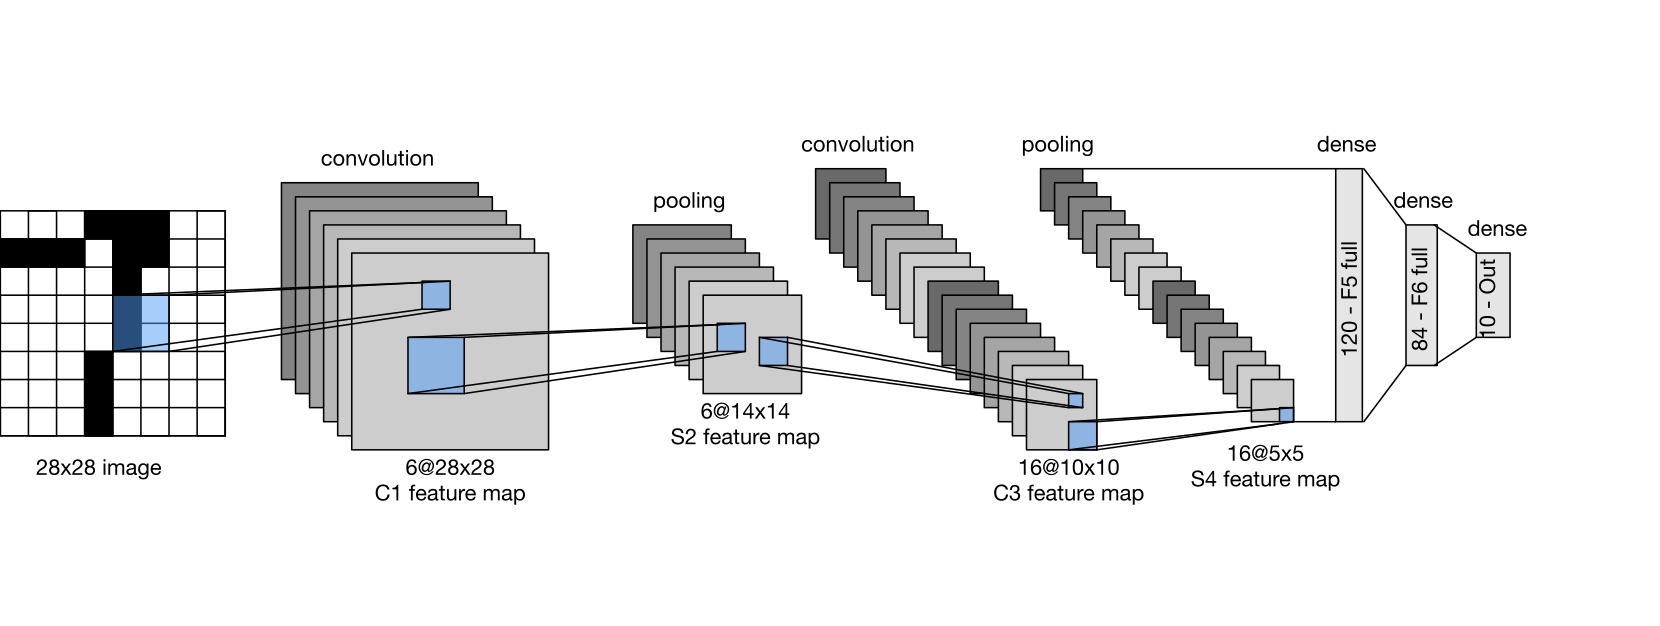

[Image Source](https://d2l.ai/chapter_convolutional-neural-networks/lenet.html#img-lenet)

In [ ]:
lenet_5_model = models.Sequential()

# Convolutional layer1: cosits of 4 filters, filter size 5x5 and stride of 2
lenet_5_model.add( layers.Conv2D(filters = 4, 
                                kernel_size = (5,5),
                                strides=2,
                                padding = "valid", 
                                activation = 'relu',
                                input_shape = (28,28,1)))
#Pooling layer 1
lenet_5_model.add(layers.MaxPooling2D(pool_size = (2,2)))

# Convolutional layer2: cosits of 10 filters, filter size 3x3 and stride of 2
lenet_5_model.add(layers.Conv2D(filters = 10, 
                                kernel_size = 3,
                                strides=2, 
                                activation = 'relu'))

#Output layer( Fully connected layers)
lenet_5_model.add(layers.Flatten())
lenet_5_model.add(layers.Dense(10, activation='softmax'))




In [231]:
lenet_5_model = models.Sequential()

# Convolutional layer1: cosits of 6 filters, filter size 5x5 and stride of 1
lenet_5_model.add( layers.Conv2D(filters = 6, 
                                 kernel_size = (5,5),
                                 strides=1, 
                                 padding = 'same', 
                                 activation = 'relu', 
                                 input_shape = (28,28,1)))
#Pooling layer 1
lenet_5_model.add(layers.MaxPooling2D(pool_size = (2,2)))

# Convolutional layer2: cosits of 16 filters, filter size 5x5 and stride of 1
lenet_5_model.add(layers.Conv2D(filters = 16,
                                 kernel_size = 5,
                                 strides=1, 
                                 activation = 'relu'))

#Pooling layer 2 
lenet_5_model.add(layers.MaxPooling2D(pool_size = (2,2)))

#Output layer( Fully connected layers)
lenet_5_model.add(layers.Flatten())
lenet_5_model.add(layers.Dense(120, activation='relu'))
lenet_5_model.add(layers.Dense(84, activation='relu'))
lenet_5_model.add(layers.Dense(10, activation='softmax'))

# Save your model
lenet_5_model.save('part2_model.h5')


lenet_5_model.summary()

Model: "sequential_50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_72 (Conv2D)              │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_48 (Flatten)            │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

### Compile and train the model


In [203]:
learning_rate=0.001
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
lenet_5_model.compile(optimizer=optimizer,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = lenet_5_model.fit(train_images, train_labels, epochs=5, 
                    validation_data=(test_images, test_labels))

Epoch 1/5


c:\Users\jenny\anaconda3\envs\endg511\Lib\site-packages\keras\src\backend\tensorflow\nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9491 - loss: 0.1682 - val_accuracy: 0.9818 - val_loss: 0.0534
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9813 - loss: 0.0592 - val_accuracy: 0.9862 - val_loss: 0.0420
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9865 - loss: 0.0433 - val_accuracy: 0.9856 - val_loss: 0.0464
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9892 - loss: 0.0341 - val_accuracy: 0.9811 - val_loss: 0.0586
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9913 - loss: 0.0267 - val_accuracy: 0.9887 - val_loss: 0.0399


### Plot accuracy and loss graphs

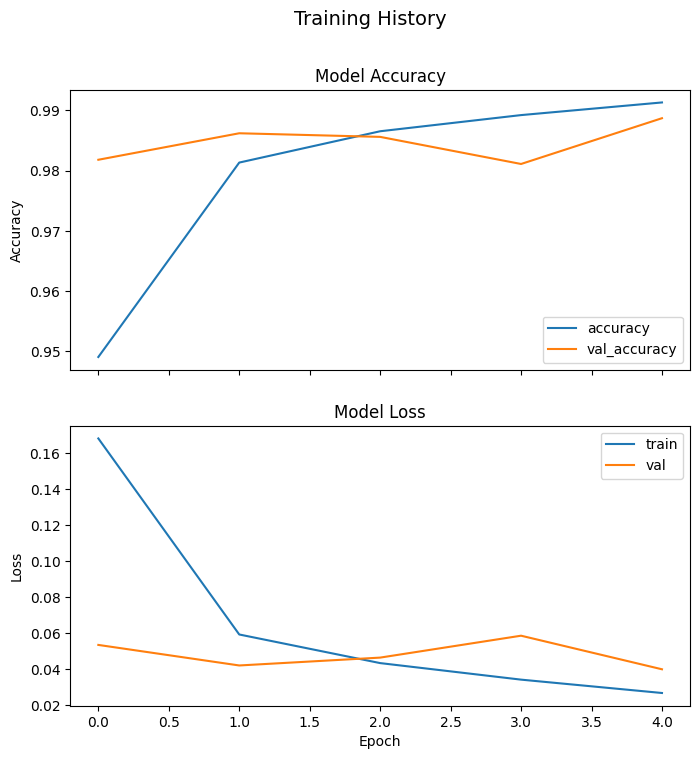

In [204]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)


axs[0].plot(history.history['accuracy'], label='accuracy')
axs[0].plot(history.history['val_accuracy'], label='val_accuracy')
axs[0].set_title('Model Accuracy')
axs[0].set_ylabel('Accuracy')
axs[0].legend(loc='best')



axs[1].plot(history.history['loss'], label='train')
axs[1].plot(history.history['val_loss'], label='val')
axs[1].set_title('Model Loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend(loc='best')


fig.suptitle('Training History', fontsize=14)


fig.savefig(f'Model_History_LR_{learning_rate}_LeNet5_MaxPooling.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

### Evaluate the model
Applying the same evaluation metrics in part 1 to evaluate the trained CNN model:

1. Model Loss and Accuracy
2. Model Size
3. Inference time

In [205]:
# Evaluate prediction accuracy
test_loss, test_acc = lenet_5_model.evaluate(test_images,  test_labels, verbose=2)


# Evaluate Model Size
def get_gzipped_model_size(file):
  # Returns size of gzipped model, in bytes.
  import os
  import zipfile

  _, zipped_file = tempfile.mkstemp('.zip')
  with zipfile.ZipFile(zipped_file, 'w', compression=zipfile.ZIP_DEFLATED) as f:
    f.write(file)

  return os.path.getsize(zipped_file)


# Evaluate Inference Time
startTime = time.time()
prediction = lenet_5_model.predict(test_images)
executionTime = (time.time() - startTime)/len(test_images)

# Print
print('\nModel Accuracy:', test_acc*100, '%')
print("Model Size: %.2f bytes" % (get_gzipped_model_size('part2_model.h5')))
print("Inference Time is", executionTime, "s")

313/313 - 1s - 3ms/step - accuracy: 0.9887 - loss: 0.0399
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Model Accuracy: 98.86999726295471 %
Model Size: 228591.00 bytes
Inference Time is 0.00012997515201568604 s


## Excercises: (2.5 points)
Q1: Briefly compare the Fully connected (FC) model in part 1 and the CNN model in part 2 in terms of the model size, accuracy and inference time.**(0.5 point)**


---




 





<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">

<div>
<strong>Fully Connected model</strong><br>
Model Accuracy: 97.680002450943 %

Model Size: 375102.00 bytes

Inference Time is 8.878178596496582e-05 s
</div>

<div>
<strong>CNN model</strong><br>
Model Accuracy: 98.7600028514862 %

Model Size: 228640.00 bytes

Inference Time is 9.980027675628662e-05 s
</div>

</div>

<p align="left">
  <img src="model_128_neurons.jpg" width="45%">
  <img src="model_LeNet_og.jpg" width="45%">
</p>

<p align="left">
  <img src="Model_History_LR_0.001_128_neurons.png" width="45%">
  <img src="Model_History_LR_0.001_LeNet5.png" width="45%">
</p>

The CNN model and the FC model have similar sizes, being 229 kbytes and 375 kbytes respectively and both have interference times in the 10's of micro-seconds. With only ~1% difference in accuracy both model perform very similarly.

Q2: Modify the two convolutional layers of the LeNet-5 stride value into 2 and discuss the effect on the model size and accuracy. If the perfromance is affected, explain the reason? **(0.5 point)**

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">

<div>
<strong>1 stride</strong><br>
Model Accuracy: 98.7600028514862 %

Model Size: 228640.00 bytes

Inference Time is 9.980027675628662e-05 s
</div>

<div>
<strong>2 stride</strong><br>
Model Accuracy: 96.46000266075134 %

Model Size: 60240.00 bytes

Inference Time is 0.00010770320892333985 s
</div>

</div>

<p align="left">
  <img src="model_LeNet_og.jpg" width="45%">
  <img src="model_LeNet_2stride.jpg" width="45%">
</p>

<p align="left">
  <img src="Model_History_LR_0.001_LeNet5.png" width="45%">
  <img src="Model_History_LR_0.001_LeNet5_2stride.png" width="45%">
</p>

The increase in stride made the model nearly 4x smaller, deacreasing the size from 229 kbytes to 60 kbytes. The reduction in size came with a decrease in accuracy of ~2.3% and an increase in interference time of ~1 micro-second. The model size decreased because it decreased the size of the frame by half as only every other pixel was the centre of the convolution, the smaller frame resulted in significantly less weights in the first fully connected layer. The resulting reduction in accuracy can be attributed to any features that where missed in the filtering stage as not every pixel was fully convolved and because there were less possible features going into the first fully connected layer.


Q3: Replace the average-pooling layer with a max-pooling layer for the LeNet-5 CNN model and discuss the effect on the trained model size and accuracy.**(0.5 point)**



<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">

<div>
<strong>Average Pooling</strong><br>
Model Accuracy: 98.7600028514862 %

Model Size: 228640.00 bytes

Inference Time is 9.980027675628662e-05 s
</div>

<div>
<strong>Max Pooling</strong><br>
Model Accuracy: 98.83000254631042 %

Model Size: 228661.00 bytes

Inference Time is 0.00012109689712524414 s
</div>

</div>

<p align="left">
  <img src="model_LeNet_og.jpg" width="45%">
  <img src="model_LeNet_MaxPooling.jpg" width="45%">
</p>

<p align="left">
  <img src="Model_History_LR_0.001_LeNet5.png" width="45%">
  <img src="Model_History_LR_0.001_LeNet5_MaxPooling.png" width="45%">
</p>

Changing the pooling style from average pooling to max pooling makes no difference in the model size. Max pooling resulted in the higher accuracy, but only by 0.07%. The biggest change was in the Inference time which increased by ~2.3 micro seconds. The change in interference time could be attributed to the higher computational complexity of comparing values instead of averaging, but this couls easily change on different hardware that more optimized for comparison.

Q4: IoT devices are limited in storage and computation resources. Therefore lightweight machine-learning or compressed models are ideal for IoT edge devices. 

In this exercise, you will modify the LeNet-5 CNN model on the MNIST dataset to reduce its size as much as possible (expecting less than 13k parameters) while maintaining inference accuracy equal to or above 95%. There is no limitation to the applied modifications. You may modify the number of filters, filter size, stride value, fully connected layers etc.**(1 point)**




<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">

<div>
<strong>Original Model</strong><br>
Model Accuracy: 98.7600028514862 %

Model Size: 228640.00 bytes

Inference Time is 9.980027675628662e-05 s
</div>

<div>
<strong>Reduced Model</strong><br>
Model Accuracy: 95.09999752044678 %

Model Size: 5482.00 bytes

Inference Time is 9.836997985839843e-05 s

</div>

</div>

<p align="left">
  <img src="LeNet_og_model.jpg" width="45%">
  <img src="LeNet_reduced_model.jpg" width="45%">
</p>
<p align="left">
  <img src="model_LeNet_og.jpg" width="45%">
  <img src="model_LeNet_95_10.jpg" width="45%">
</p>

<p align="left">
  <img src="Model_History_LR_0.001_LeNet5.png" width="45%">
  <img src="Model_History_LR_0.001_LeNet5_95_10.png" width="45%">
</p>

The reduced model has only 4 filters and a stride of 2 in the first convolutional layer, with no padding. The new model then uses Maxpooling into the second convolutional layer that has only 10 filters of size 3x3 and a stride of 2. The second maxpooling is removed. Then there is only one fully connected layer after it's flattened, with only 10 neurons. All of these changes reduce the size of the model from 61,706 parameters down to 884 parameters, reducing the overall size from 229 kbytes to 5.5 kbytes, which is well below 13 kbytes. The interference time decreased by 0.7 micro-seconds and the accuracy decreased by ~3.7% down to 95.1%. Which just barely stays above the 95% accuracy minimum. 

